In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
model = load_model("hurricane_damage_model.keras")
model.summary()

c:\Users\IDEAPAD\Desktop\Urban-Infrastructure-Damage-\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,242,732 (275.58 MB)

 Trainable params: 25,690,625 (98.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

 Optimizer params: 25,690,627 (98.00 MB)

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_dir = "dataset/test_another"

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 9000 images belonging to 2 classes.


In [6]:
predictions = model.predict(test_generator)

print("Predictions generated")

282/282 ━━━━━━━━━━━━━━━━━━━━ 582s 2s/step
Predictions generated


In [7]:

y_true = test_generator.classes

print("Predictions shape:", predictions.shape)
print("True labels shape:", y_true.shape)

Predictions shape: (9000, 1)
True labels shape: (9000,)


In [8]:
import numpy as np

y_pred = (predictions > 0.5).astype(int)

print("Predicted labels shape:", y_pred.shape)

Predicted labels shape: (9000, 1)


In [9]:
y_pred = y_pred.flatten()

print("New prediction shape:", y_pred.shape)

New prediction shape: (9000,)


In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[7546  454]
 [  81  919]]


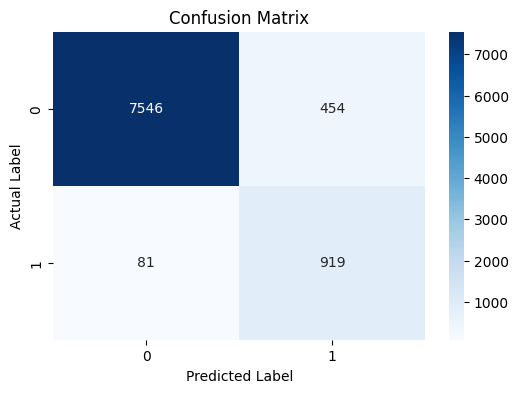

In [11]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [12]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred)

print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.94      0.97      8000
           1       0.67      0.92      0.77      1000

    accuracy                           0.94      9000
   macro avg       0.83      0.93      0.87      9000
weighted avg       0.95      0.94      0.94      9000



In [13]:
from sklearn.metrics import log_loss

loss = log_loss(y_true, predictions)

print("Log Loss:", loss)

Log Loss: 0.1490572419000979


In [ ]:
""""
Model Evaluation Summary

Test Dataset Size: 9000 images

Accuracy: 94%

Confusion Matrix:
True Negatives: 7546
False Positives: 454
False Negatives: 81
True Positives: 919

Classification Report Highlights:
Recall for damaged buildings: 0.92
Precision for damaged buildings: 0.67
F1 Score for damaged buildings: 0.77

Log Loss: 0.149

Observations:
The model performs very well in identifying undamaged buildings with high precision (0.99).
The recall for damaged buildings is 0.92, meaning the model successfully detects most damaged structures.
Only 81 damaged buildings were missed out of 1000, which indicates strong detection capability.

Conclusion:
The model demonstrates strong performance for urban infrastructure damage classification and is suitable for identifying buildings at risk after natural disasters.
"""